In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [2]:
earthquakes = pd.read_csv(
    "data/processed/earthquakes_processed.csv"
)

earthquakes.head()

,Time,Date,Year,Month,Day,Hour,Weekday,Latitude,Longitude,Depth_km,Magnitude,Location
0,2025-12-30 23:51:36.674000+00:00,2025-12-30,2025,12,30,23,Tuesday,39.4639,142.7562,35.000,4.8,"69 km E of Yamada, Japan"
1,2025-12-30 22:36:09.826000+00:00,2025-12-30,2025,12,30,22,Tuesday,3.0448,128.8654,10.000,4.5,"173 km NNE of Tobelo, Indonesia"
2,2025-12-30 22:25:43.819000+00:00,2025-12-30,2025,12,30,22,Tuesday,60.5503,-140.1190,5.000,3.3,"113 km N of Yakutat, Alaska"
3,2025-12-30 22:19:46.317000+00:00,2025-12-30,2025,12,30,22,Tuesday,39.5984,143.3045,27.735,4.8,"117 km E of Miyako, Japan"
4,2025-12-30 22:14:01.822000+00:00,2025-12-30,2025,12,30,22,Tuesday,62.7050,-149.2790,59.600,2.5,"51 km ENE of Chase, Alaska"


In [3]:
earthquakes["Time"] = pd.to_datetime(
    earthquakes["Time"],
    format="mixed",
    utc=True,
    errors="coerce"
)

earthquakes = earthquakes.dropna(subset=["Time"])

In [4]:
earthquakes["Region"] = (
    earthquakes["Location"]
    .fillna("Unknown")
    .str.split(",")
    .str[-1]
    .str.strip()
)

earthquakes[["Location", "Region"]].head()

,Location,Region
0,"69 km E of Yamada, Japan",Japan
1,"173 km NNE of Tobelo, Indonesia",Indonesia
2,"113 km N of Yakutat, Alaska",Alaska
3,"117 km E of Miyako, Japan",Japan
4,"51 km ENE of Chase, Alaska",Alaska


In [5]:
top_regions = (
    earthquakes["Region"]
    .value_counts()
    .head(10)
)

print(top_regions)

Region
Alaska              4583
Russia              3983
Indonesia            878
Japan                811
Philippines          596
CA                   596
Puerto Rico          532
Papua New Guinea     395
Chile                357
Tonga                271
Name: count, dtype: int64


In [6]:
selected_region = top_regions.index[0]

print("Forecasting region:", selected_region)

Forecasting region: Alaska


In [7]:
region_data = earthquakes[
    earthquakes["Region"] == selected_region
].copy()

region_data["Date"] = region_data["Time"].dt.date

daily_region = (
    region_data
    .groupby("Date")
    .size()
    .reset_index(name="Earthquake_Count")
)

daily_region["Date"] = pd.to_datetime(
    daily_region["Date"]
)

daily_region = daily_region.set_index("Date")

daily_region.head()

,Earthquake_Count
Date,
2025-05-04,1
2025-05-05,12
2025-05-06,23
2025-05-07,21
2025-05-08,17


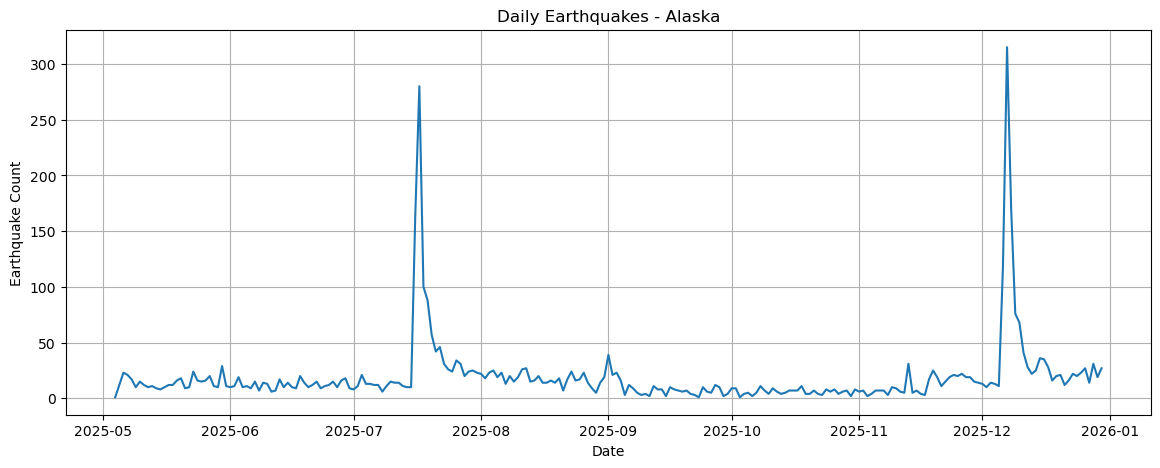

In [8]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_region.index,
    daily_region["Earthquake_Count"]
)

plt.title(f"Daily Earthquakes - {selected_region}")

plt.xlabel("Date")

plt.ylabel("Earthquake Count")

plt.grid(True)

plt.show()

In [9]:
model = ARIMA(
    daily_region["Earthquake_Count"],
    order=(1,1,1)
)

model_fit = model.fit()

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [10]:
forecast = model_fit.forecast(30)

forecast

2025-12-31    33.379265
2026-01-01    29.568294
2026-01-02    31.844967
2026-01-03    30.484883
2026-01-04    31.297397
2026-01-05    30.812001
2026-01-06    31.101976
2026-01-07    30.928745
2026-01-08    31.032234
2026-01-09    30.970410
2026-01-10    31.007343
2026-01-11    30.985279
2026-01-12    30.998460
2026-01-13    30.990586
2026-01-14    30.995290
2026-01-15    30.992480
2026-01-16    30.994159
2026-01-17    30.993156
2026-01-18    30.993755
2026-01-19    30.993397
2026-01-20    30.993611
2026-01-21    30.993483
2026-01-22    30.993559
2026-01-23    30.993514
2026-01-24    30.993541
2026-01-25    30.993525
2026-01-26    30.993534
2026-01-27    30.993529
2026-01-28    30.993532
2026-01-29    30.993530
Freq: D, Name: predicted_mean, dtype: float64

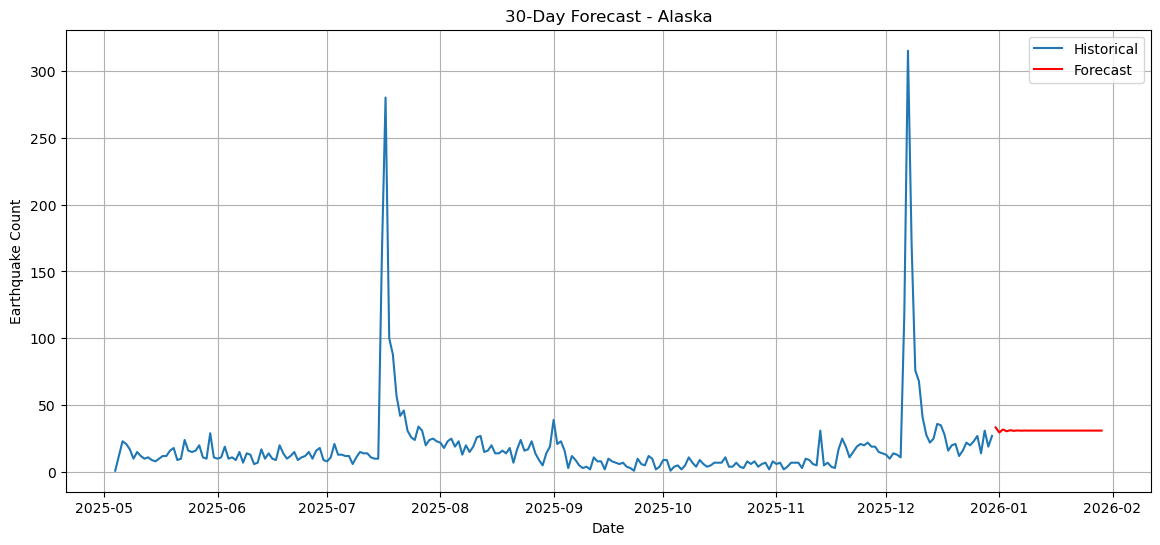

In [11]:
future_dates = pd.date_range(
    start=daily_region.index[-1] + pd.Timedelta(days=1),
    periods=30
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_region.index,
    daily_region["Earthquake_Count"],
    label="Historical"
)

plt.plot(
    future_dates,
    forecast,
    color="red",
    label="Forecast"
)

plt.title(f"30-Day Forecast - {selected_region}")

plt.xlabel("Date")
plt.ylabel("Earthquake Count")

plt.legend()
plt.grid(True)

plt.show()

In [14]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast
})

forecast_df.to_csv(
    f"outputs/forecasts/{selected_region}_forecast.csv",
    index=False
)

forecast_df.head()

,Date,Forecast
2025-12-31,2025-12-31,33.379265
2026-01-01,2026-01-01,29.568294
2026-01-02,2026-01-02,31.844967
2026-01-03,2026-01-03,30.484883
2026-01-04,2026-01-04,31.297397


In [15]:
daily_region = daily_region.asfreq("D", fill_value=0)

In [16]:
model = ARIMA(
    daily_region["Earthquake_Count"],
    order=(1,1,1)
)

model_fit = model.fit()